In [1]:
import pandas as pd
url='https://helioforecast.space/static/sync/icmecat/HELIO4CAST_ICMECAT_v23.csv'
ic=pd.read_csv(url)
ic.keys()
# print(ic.icme_start_time)

ic = ic.truncate(before=0, after=1901)
# ic.icme_start_time
# print(ic.sc_insitu)

# ic = ic.loc[ic['sc_insitu'] == "Wind"]
# print(ic.icme_start_time)
# print(ic.sc_insitu.unique)


In [77]:
# ic.icme_start_time.unique
# ic.mo_end_time.unique

# df_merged = pd.concat([ic.icme_start_time, ic.mo_end_time], ignore_index=True, sort=False)
# print(df_merged)
# print(df_merged.unique)
# ic.icme_duration

# print(ic.icme_start_time[0])

from datetime import datetime

DayRange = []
Wind = 0
NotWind = 0
for i in range(len(ic.icme_start_time)):
    if ic.sc_insitu[i] == "Wind":
        Wind = Wind + 1
        if ic.icme_start_time[i][0:10] == ic.mo_end_time[i][0:10]:
            DayRange.append("Same day")
        else:
            Diff = datetime.fromisoformat(ic.mo_end_time[i]) - datetime.fromisoformat(ic.icme_start_time[i])
            DayRange.append("Multi-day , over " + str(Diff.days+2)[0:6] + " day(s)")
    else:
        NotWind = NotWind + 1

print(DayRange)
print(Wind)
print(NotWind)


UniqueDayCounts = {i:DayRange.count(i) for i in DayRange}
print("UniqueDayCounts: " + str(UniqueDayCounts))

# Before Wind only data selected
# print(ic.icme_start_time[5], ic.mo_end_time[5]) # same day
# print(ic.icme_start_time[7], ic.mo_end_time[7]) # 2-3 hours apart but over the day change at midnight
# print(ic.icme_start_time[10], ic.mo_end_time[10]) # midnight to nine am the next day (two dates, and over 24 hours)

# Number of days to remove
# UniqueDayCounts: {'Multi-day , over 3 day(s)': 248, 'Multi-day , over 2 day(s)': 147, 'Same day': 96, 'Multi-day , over 4 day(s)': 43, 'Multi-day , over 5 day(s)': 6}
# 'Same day': 96 # number of ICMEs that start and end on the same day
# 'Multi-day , over 2 day(s)': 147 # number of ICMEs that start and end on different days but last under 24 hours
# 'Multi-day , over 3 day(s)': 248 # number if ICMES that last over 2 dates (and longer than 24 hours)
# 'Multi-day , over 4 day(s)': 43 # number if ICMES that last over 3 dates 
# 'Multi-day , over 5 day(s)': 6 # number if ICMES that last over 4 dates 


# Total number of days to remove (assuming no overlaps)
# Total = 468 + (577*2) + (638*3) + (152*4) + (41*5) + (17*6) + (6*7) + (1*8) + (2*9)
Total = 96 + (147*2) + (248*3) + (43*4) + (6*5)
print(Total)

# Total number of days in the years
# NOTE: The catalogue only goes to 2025-06-22 but my yearly histograms use data up to partway though 2026
NoOfDays = (2025-1996)*365
print(NoOfDays)
# Removing each day that a CME occurs at ANY SPACECRAFT would make me lose half my data.
# Removing each day that a CME occurs at Wind would make me lose half my data.

print(Total/NoOfDays)

['Multi-day , over 3 day(s)', 'Multi-day , over 3 day(s)', 'Multi-day , over 2 day(s)', 'Multi-day , over 3 day(s)', 'Multi-day , over 2 day(s)', 'Multi-day , over 2 day(s)', 'Same day', 'Multi-day , over 2 day(s)', 'Same day', 'Same day', 'Multi-day , over 2 day(s)', 'Multi-day , over 2 day(s)', 'Multi-day , over 3 day(s)', 'Multi-day , over 3 day(s)', 'Multi-day , over 3 day(s)', 'Multi-day , over 2 day(s)', 'Same day', 'Multi-day , over 2 day(s)', 'Same day', 'Multi-day , over 2 day(s)', 'Same day', 'Same day', 'Multi-day , over 2 day(s)', 'Multi-day , over 2 day(s)', 'Same day', 'Multi-day , over 2 day(s)', 'Multi-day , over 2 day(s)', 'Multi-day , over 2 day(s)', 'Same day', 'Multi-day , over 2 day(s)', 'Multi-day , over 2 day(s)', 'Multi-day , over 2 day(s)', 'Same day', 'Multi-day , over 2 day(s)', 'Multi-day , over 4 day(s)', 'Multi-day , over 2 day(s)', 'Multi-day , over 5 day(s)', 'Multi-day , over 2 day(s)', 'Same day', 'Multi-day , over 2 day(s)', 'Multi-day , over 3 day(s)

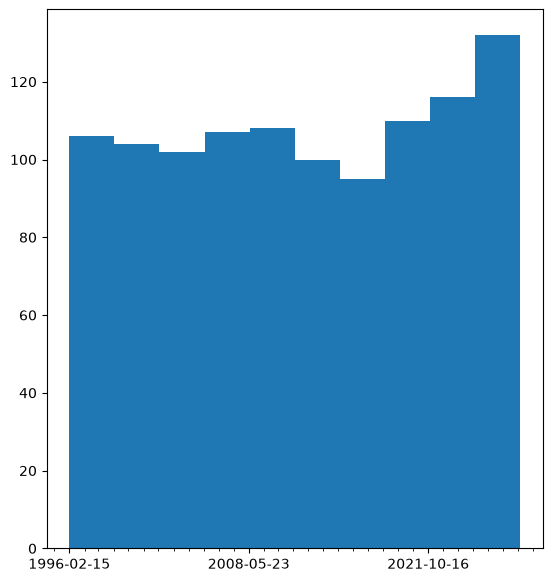

In [55]:
import matplotlib.pyplot as plt
import numpy as np 

WindOnly = ic.loc[ic['sc_insitu'] == "Wind"]
# print(WindOnly.icme_start_time)
# print(WindOnly.sc_insitu.unique)

y = np.ones([len(WindOnly.icme_start_time)])

x = []
for i in WindOnly.icme_start_time:
    x.append( i[0:10] )

for i in WindOnly.mo_end_time:
    x.append( i[0:10] )

import matplotlib.dates as mdates

fig, axs = plt.subplots(1, 1, figsize=(6.4, 7))
# print(x)
# plt.plot(x, y)
plt.hist(sorted(x))
axs.xaxis.set_major_locator(mdates.YearLocator())
axs.xaxis.set_minor_locator(mdates.MonthLocator())
plt.show()


[ 8. 21. 30. 16. 31. 23. 20. 10. 13. 16. 13.  7.  5. 15. 15. 22. 30. 21.
 15. 14.  9. 10.  8.  6. 10. 31. 23. 32. 49. 17.]


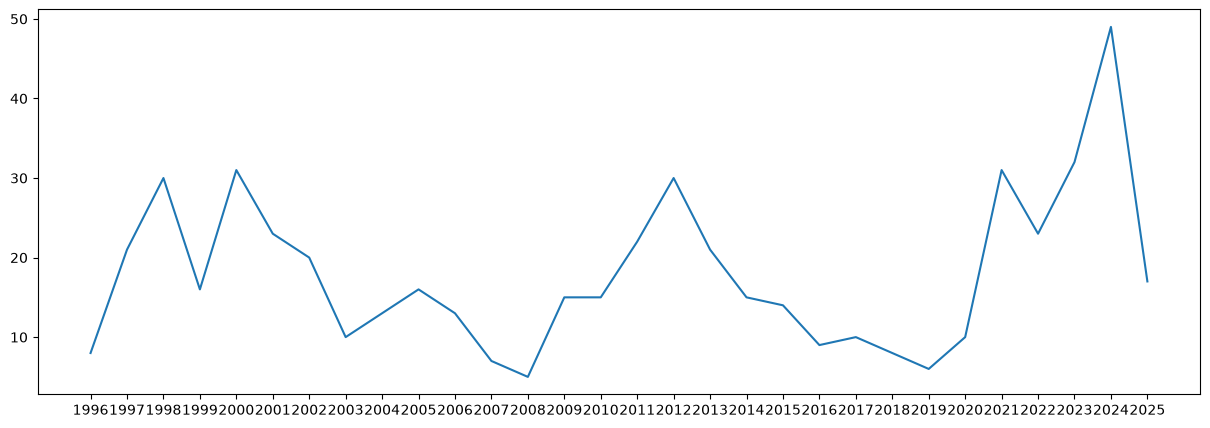

In [61]:

Years = ["1996", "1997", "1998", "1999", "2000", "2001", "2002", "2003", "2004", "2005", "2006", 
         "2007", "2008", "2009", "2010", "2011", "2012", "2013", "2014", "2015", "2016", "2017", 
         "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"]
YearCounts=np.zeros(len(Years))

for l in range(len(Years)):
    for j in WindOnly.icme_start_time:
        Counter = 0
        if j[0:4] == Years[l]:
            YearCounts[l] = YearCounts[l] + 1

print(YearCounts)

fig, axs = plt.subplots(1,1, figsize=(15,5))
plt.plot(Years, YearCounts)

Files Downloaded: 100%|██████████| 1/1 [00:00<00:00, 60.65file/s]
/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  6.82file/s]
/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function

['19960101', '19970101', '19980101', '19990101', '20000101', '20010101', '20020101', '20030101', '20040101', '20050101', '20060101', '20070101', '20080101', '20090101', '20100101', '20110101', '20120101', '20130101', '20140101', '20150101', '20160101', '20170101', '20180101', '20190101', '20200101', '20210101', '20220101', '20230101', '20240101', '20250101', '20260101']
[['1996-01-01', '1996-12-31'], ['1997-01-01', '1997-12-31'], ['1998-01-01', '1998-12-31'], ['1999-01-01', '1999-12-31'], ['2000-01-01', '2000-12-31'], ['2001-01-01', '2001-12-31'], ['2002-01-01', '2002-12-31'], ['2003-01-01', '2003-12-31'], ['2004-01-01', '2004-12-31'], ['2005-01-01', '2005-12-31'], ['2006-01-01', '2006-12-31'], ['2007-01-01', '2007-12-31'], ['2008-01-01', '2008-12-31'], ['2009-01-01', '2009-12-31'], ['2010-01-01', '2010-12-31'], ['2011-01-01', '2011-12-31'], ['2012-01-01', '2012-12-31'], ['2013-01-01', '2013-12-31'], ['2014-01-01', '2014-12-31'], ['2015-01-01', '2015-12-31'], ['2016-01-01', '2016-12-31

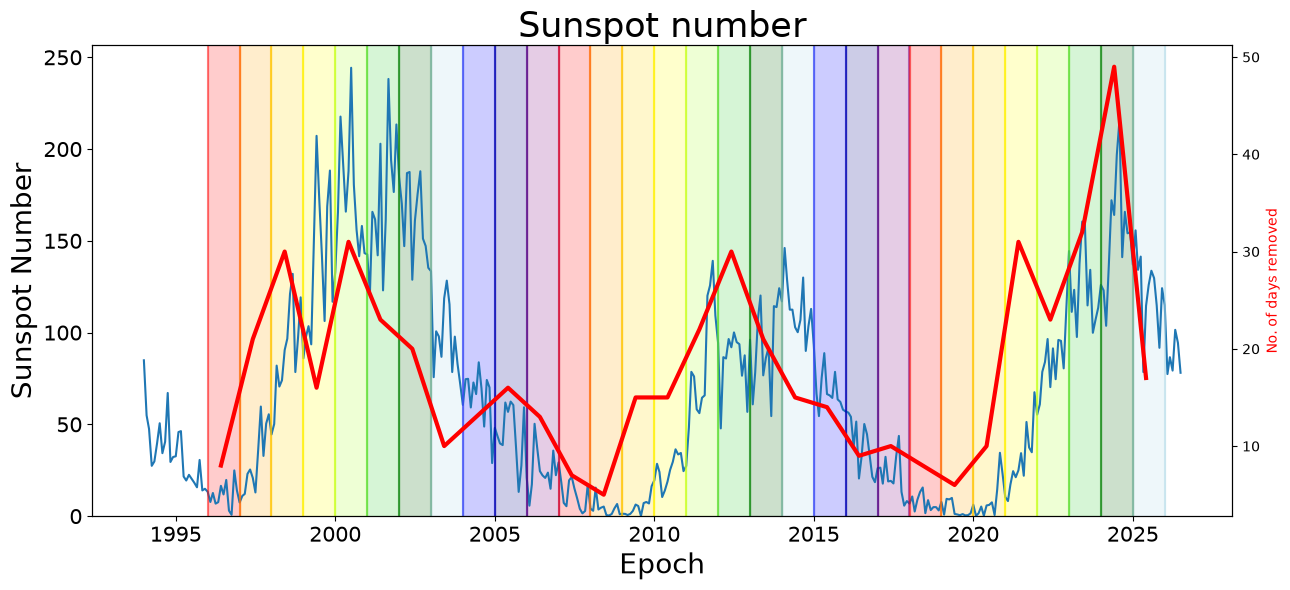

In [79]:
#Imports
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.time import Time, TimeDelta
from astropy.visualization import time_support

import sunpy.timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.time import TimeRange

import numpy as np
import pandas as pd

# get data
time_range = TimeRange("1994-01-01 00:00", Time.now()) # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
result = Fido.search(a.Time(time_range), a.Instrument('noaa-indices')) # fido search for the noaa indices in the time range
f_noaa_indices = Fido.fetch(result)
result = Fido.search(a.Time(time_range.end, time_range.end + TimeDelta(4 * u.year)),
                     a.Instrument('noaa-predict')) # get the predicted sunspot numbers from NOAA (4 years in future)
f_noaa_predict = Fido.fetch(result)

#loading data into TimeSeries objects
noaa = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(time_range) 
noaa_predict = ts.TimeSeries(f_noaa_predict, source='noaapredictindices')

TitleSize = 25
AxisSize = 20
TickSize = 15

Start  = "1996-01-01 00:00" # from SIDC
End  = "2026-12-31 23:59" 

def Yearly(startDate, endDate): #ReadDatesForFileFinding
    YearlyRange = pd.date_range(startDate, endDate, freq='YS').strftime("%Y%m%d").tolist()
    return YearlyRange

YearlyRange = Yearly(Start, End)
print(YearlyRange)

StartAndEnd = []
for i in range(len(YearlyRange)-1):
    StartDate = YearlyRange[i]
    EndDate = YearlyRange[i][0:4] + "1231"
    # print(StartDate, EndDate)
    StartAndEnd.append([StartDate[0:4] + "-" + StartDate[4:6] + "-" + StartDate[6:8], EndDate[0:4] + "-" + EndDate[4:6] + "-" + EndDate[6:8]])

print(StartAndEnd)


time_support()
# fig, ax = plt.subplots(figsize=(13,6))
fig, ax1 = plt.subplots(figsize=(13,6))
ax1.plot(noaa.time, noaa.quantity('sunspot RI'), label='Sunspot Number')

import datetime as date
times = [date.datetime(1995,1,1), date.datetime(2000,1,1), date.datetime(2005,1,1), date.datetime(2010,1,1), date.datetime(2015,1,1), date.datetime(2020,1,1), date.datetime(2025,1,1)]
t_yr = [tm.year for tm in times]
t=Time(times, format='datetime')
ax1.set_xticks(t,t_yr)

# from astropy.time import Time
# import datetime as date
# times = [date.datetime(1996,1,1), date.datetime(1997,1,1)]
# t = Time(times, format='datetime')#, scale='utc')
# # print(t.decimalyear(precision=2))
# plt.xticks(t, rotation=45)
# # ax.get_xticks


# print(str(noaa.time[0])[0:4])
# print(type(noaa.time))

# dfYears = pd.DataFrame({'Date':noaa.time, 'Sunspots':noaa.quantity('sunspot RI')})
# years = []
# for j in range(len(noaa.time)):
#     years.append(str(noaa.time[j])[0:4])

# Set = set(years)
# Years = list(Set)
# from datetime import date
# YearsTime = []
# for k in range(len(Years)):
#     YearsTime.append(date(int(Years[k]), 1, 1))
# print(YearsTime)

# plt.xticks(YearsTime, rotation=45)
# # print(type(noaa.time[0]))
# jyear = np.linspace(2000, 2001, 20)
# t = Time(jyear, format='jyear', scale='utc')
# # fig, ax = plt.subplots()
# ax.xaxis.axis_date()
# fig.autofmt_xdate()  # orient date labels at a slant

# years = [date.year for date in df['Date']]

# plt.xticks(df['Date'], years, rotation=45)

# ax.xaxis.axis_date()

ax1.set_ylim(bottom=0)
ax1.set_ylabel('Sunspot Number', fontsize=AxisSize)
ax1.set_xlabel('Epoch', fontsize=AxisSize)

plt.xticks(fontsize=TickSize)
plt.yticks(fontsize=TickSize)
plt.title("Sunspot number", fontsize=TitleSize)

dateRanges = []
for i in range(len(StartAndEnd)):
    dateRanges.append([Time(StartAndEnd[i][0]).jd1-2400000, Time(StartAndEnd[i][1]).jd1-2400000])

# Colour = ['pink','brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet','gold', 'pink','brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink'] # need 30
Colours = ["red", "orange", "gold", "yellow", "greenyellow", "limegreen", "darkgreen", "lightblue", "blue", "darkblue", "purple", "red", "orange", "gold", "yellow", "greenyellow", "limegreen", "darkgreen", "lightblue", "blue", "darkblue", "purple", "red", "orange", "gold", "yellow", "greenyellow", "limegreen", "darkgreen", "lightblue", "blue", "darkblue", "purple"]

for i in range(len(dateRanges)):
    # print(len(dateRanges))
    ax1.axvline(dateRanges[i][0], color=Colours[i], alpha = 0.5)
    # ax.axvspan(dateRanges[i][0], dateRanges[i][1], color=Colours[i], alpha=0.2, label = StartAndEnd[i][0] + "->" + StartAndEnd[i][1])
    ax1.axvspan(dateRanges[i][0], dateRanges[i][1], color=Colours[i], alpha=0.2, label = StartAndEnd[i][0][0:4])
    ax1.axvline(dateRanges[i][1], color=Colours[i], alpha = 0.5)

# TandCAlpha = 1
# TandCAlpha2 = 0.7
# TandCPosition1 = 0
# TandCPosition2 = 0.05

#Tindale and Chapman - "These dates were chosen based on the sunspot number, as in Hush et al. (2015)."
# ax.axvspan(Time('1995-12-01').jd1-2400000, Time('1996-11-30').jd1-2400000, TandCPosition1, TandCPosition2, color='grey', alpha=TandCAlpha)#, label = "T&C C23 minimum")
# ax.axvspan(Time('1999-10-01').jd1-2400000, Time('2000-09-30').jd1-2400000, TandCPosition1, TandCPosition2, color='grey', alpha=TandCAlpha)#, label = "T&C C23 maximum")
# ax.axvspan(Time('2007-08-01').jd1-2400000, Time('2008-07-31').jd1-2400000, TandCPosition1, TandCPosition2, color='grey', alpha=TandCAlpha)#, label = "T&C C24 minimum")
# ax.axvspan(Time('2013-11-01').jd1-2400000, Time('2014-10-31').jd1-2400000, TandCPosition1, TandCPosition2, color='grey', alpha=TandCAlpha)#, label = "T&C C24 maximum")

# C23MinMidtimerange = TimeRange("1996-05-01", "1996-05-31") # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
# C23MinMid = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(C23MinMidtimerange)
# # C23Mintime_range = TimeRange("1995-12-01", "1996-11-30") # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
# # C23Minimum = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(C23Mintime_range)
# print(C23MinMid.quantity) 
# ax.axvline(Time('1996-05-01').jd1-2400000, color='red')




Years = ["1996", "1997", "1998", "1999", "2000", "2001", "2002", "2003", "2004", "2005", "2006", 
         "2007", "2008", "2009", "2010", "2011", "2012", "2013", "2014", "2015", "2016", "2017", 
         "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"]
YearCounts=np.zeros(len(Years))

for l in range(len(Years)):
    for j in WindOnly.icme_start_time:
        Counter = 0
        if j[0:4] == Years[l]:
            YearCounts[l] = YearCounts[l] + 1

print(YearCounts)

# timesICME = [date.datetime(1995,6,1), date.datetime(2000,6,1), date.datetime(2005,6,1), date.datetime(2010,6,1), date.datetime(2015,6,1), date.datetime(2020,6,1), date.datetime(2025,6,1)]
# t_yr = [tm.year for tm in timesICME]
# t=Time(timesICME, format='datetime')
# # fig, axs = plt.subplots(1,1, figsize=(15,5))
# subset = [YearCounts[0], YearCounts[5], YearCounts[10], YearCounts[15], YearCounts[20], YearCounts[25], YearCounts[26]]

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

times = [date.datetime(1996,6,1), date.datetime(1997,6,1), date.datetime(1998,6,1), date.datetime(1999,6,1), date.datetime(2000,6,1), date.datetime(2001,6,1), date.datetime(2002,6,1), date.datetime(2003,6,1), date.datetime(2004,6,1), date.datetime(2005,6,1), date.datetime(2006,6,1), date.datetime(2007,6,1), date.datetime(2008,6,1), date.datetime(2009,6,1), date.datetime(2010,6,1), date.datetime(2011,6,1), date.datetime(2012,6,1), date.datetime(2013,6,1), date.datetime(2014,6,1), date.datetime(2015,6,1), date.datetime(2016,6,1), date.datetime(2017,6,1), date.datetime(2018,6,1), date.datetime(2019,6,1), date.datetime(2020,6,1), date.datetime(2021,6,1), date.datetime(2022,6,1), date.datetime(2023,6,1), date.datetime(2024,6,1), date.datetime(2025,6,1)]
t_yr = [tm.year for tm in times]
t=Time(times, format='datetime')
# ax.set_xticks(t,t_yr)

ax2.plot(t, YearCounts, color = "red", linewidth=3)
ax2.set_ylabel('No. of days removed', color="red")  # we already handled the x-label with ax1



# fig.legend(loc="outside right", fontsize=8)
fig.tight_layout()  # otherwise the right y-label is slightly clipped

# plt.savefig("YearlySunspotNumber.png")
plt.show()



# # Create some mock data
# t = np.arange(0.01, 10.0, 0.01)
# data1 = np.exp(t)
# data2 = np.sin(2 * np.pi * t)

# fig, ax1 = plt.subplots()

# color = 'tab:red'
# ax1.set_xlabel('time (s)')
# ax1.set_ylabel('exp', color=color)
# ax1.plot(t, data1, color=color)
# ax1.tick_params(axis='y', labelcolor=color)

# ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

# color = 'tab:blue'
# ax2.set_ylabel('sin', color=color)  # we already handled the x-label with ax1
# ax2.plot(t, data2, color=color)
# ax2.tick_params(axis='y', labelcolor=color)

# fig.tight_layout()  # otherwise the right y-label is slightly clipped
# plt.show()

Search catalogue for CME times for specific spacecraft?

Decide how to remove the times (start/end of MO? ICME start time + ICME duration? MO duration?

How do they define MO and compare it to CME defn?

Sometimes one without the other